In [1]:
import pickle
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_max_pool
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

C:\Users\noton\miniconda3\envs\Deep2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = GCNConv(30, 256)
        self.conv2 = GCNConv(256, 256)
        self.conv3 = GCNConv(256, 256)
        self.conv4 = GCNConv(256, 256)
        self.fc1 = nn.Linear(256, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = self.conv4(x, edge_index)
        x = F.relu(x)
        x = global_max_pool(x, data.batch)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        return x

In [3]:
def custom_collate(batch):
    data_list, target_list = zip(*batch)
    batch_data = Batch.from_data_list(data_list)
    batch_target = torch.stack(target_list)
    return batch_data, batch_target

Dataset :  AI
Epoch 1, Validation Loss: 0.3204943268030848
Epoch 2, Validation Loss: 0.2255545813912784
Epoch 3, Validation Loss: 0.17185696061715552
Epoch 4, Validation Loss: 0.14222823013655939
Epoch 5, Validation Loss: 0.12565150231678363
Epoch 6, Validation Loss: 0.11644748435039876
Epoch 7, Validation Loss: 0.11407369841697132
Epoch 8, Validation Loss: 0.11155180682845954
Epoch 9, Validation Loss: 0.10446043418297968
Epoch 10, Validation Loss: 0.09341946827815743
Epoch 11, Validation Loss: 0.09714795576923475
Epoch 12, Validation Loss: 0.1096243970248428
Epoch 13, Validation Loss: 0.10535438076826632
Epoch 14, Validation Loss: 0.0946897574897184
Epoch 15, Validation Loss: 0.08916725151313486
Epoch 16, Validation Loss: 0.07414637640717764
Epoch 17, Validation Loss: 0.07816819101479963
Epoch 18, Validation Loss: 0.07126356687182021
Epoch 19, Validation Loss: 0.06845680798019292
Epoch 20, Validation Loss: 0.06719967757965087
Epoch 21, Validation Loss: 0.06490244786692578
Epoch 22, Va

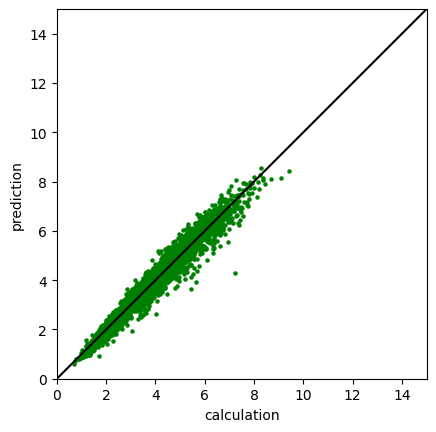

Dataset :  AI2
Epoch 1, Validation Loss: 0.62739100411908
Epoch 2, Validation Loss: 0.23606909692365924
Epoch 3, Validation Loss: 0.19322201961017146
Epoch 4, Validation Loss: 0.14324824831881255
Epoch 5, Validation Loss: 0.1276453127705667
Epoch 6, Validation Loss: 0.12325415004177617
Epoch 7, Validation Loss: 0.11000104696181065
Epoch 8, Validation Loss: 0.09637329449928347
Epoch 9, Validation Loss: 0.10321043277294059
Epoch 10, Validation Loss: 0.0993429110848354
Epoch 11, Validation Loss: 0.08575555011253248
Epoch 12, Validation Loss: 0.07818546466017054
Epoch 13, Validation Loss: 0.08010275088129801
Epoch 14, Validation Loss: 0.07604900383594546
Epoch 15, Validation Loss: 0.07150160556971874
Epoch 16, Validation Loss: 0.07133233221968638
Epoch 17, Validation Loss: 0.07318329411997893
Epoch 18, Validation Loss: 0.07518611863344249
Epoch 19, Validation Loss: 0.0693237612011481
Epoch 20, Validation Loss: 0.06042922906107445
Epoch 21, Validation Loss: 0.060185028910596565
Epoch 22, Va

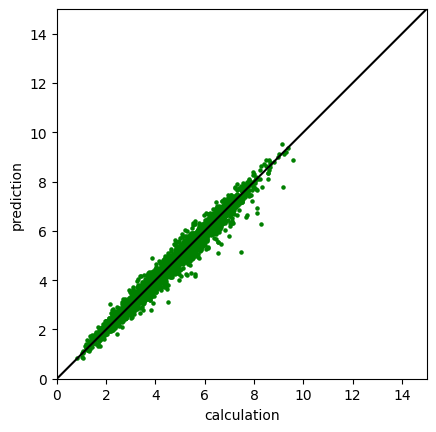

Dataset :  Random
Epoch 1, Validation Loss: 0.3773018272965967
Epoch 2, Validation Loss: 0.2702384615483388
Epoch 3, Validation Loss: 0.1961766723337755
Epoch 4, Validation Loss: 0.14761467208166065
Epoch 5, Validation Loss: 0.13355286788917983
Epoch 6, Validation Loss: 0.12446276483901055
Epoch 7, Validation Loss: 0.12227926540093949
Epoch 8, Validation Loss: 0.09904701191627217
Epoch 9, Validation Loss: 0.09581679012329425
Epoch 10, Validation Loss: 0.09598318079083397
Epoch 11, Validation Loss: 0.10737131567597724
Epoch 12, Validation Loss: 0.1080731504921438
Epoch 13, Validation Loss: 0.094961517412171
Epoch 14, Validation Loss: 0.10252753951866679
Epoch 15, Validation Loss: 0.09961183164374691
Epoch 16, Validation Loss: 0.08367498068870374
Epoch 17, Validation Loss: 0.0751655198488611
Epoch 18, Validation Loss: 0.07131517708448395
Epoch 19, Validation Loss: 0.06800294428862026
Epoch 20, Validation Loss: 0.06609847703906084
Epoch 21, Validation Loss: 0.06497437698121432
Epoch 22, V

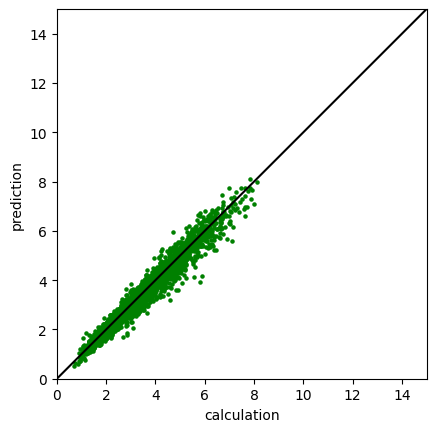

Dataset :  Human
Epoch 1, Validation Loss: 0.5204858042021726
Epoch 2, Validation Loss: 0.30269050747804765
Epoch 3, Validation Loss: 0.16841295365953896
Epoch 4, Validation Loss: 0.12488047046615075
Epoch 5, Validation Loss: 0.1266312845363127
Epoch 6, Validation Loss: 0.0812388775731817
Epoch 7, Validation Loss: 0.0676485247369503
Epoch 8, Validation Loss: 0.06053443652819858
Epoch 9, Validation Loss: 0.05370352051004869
Epoch 10, Validation Loss: 0.04750286484653928
Epoch 11, Validation Loss: 0.04439861687393171
Epoch 12, Validation Loss: 0.042885784787482804
Epoch 13, Validation Loss: 0.041936583336136556
Epoch 14, Validation Loss: 0.04142504118523189
Epoch 15, Validation Loss: 0.038597129069086036
Epoch 16, Validation Loss: 0.035653304373390524
Epoch 17, Validation Loss: 0.030059425478585686
Epoch 18, Validation Loss: 0.03149598143754208
Epoch 19, Validation Loss: 0.024667843023945746
Epoch 20, Validation Loss: 0.024709532294893474
Epoch 21, Validation Loss: 0.02126602776659875
Ep

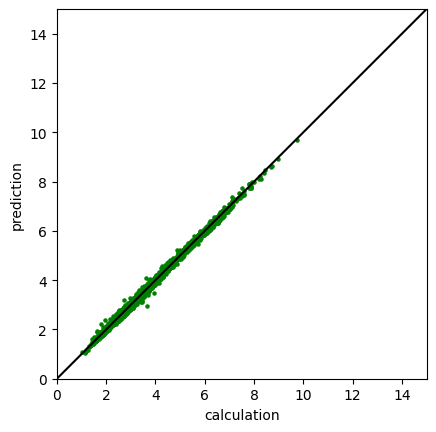

In [4]:
torch.manual_seed(0)

target_data = "kappa3"
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')
    
for d in ["AI", "AI2", "Random", "Human"]:
    torch.manual_seed(0)
    print('Dataset : ', d)
    dataset = d

    with open(f'data_{dataset}/data_train_list.pkl', 'rb') as f:
        data_train_list = pickle.load(f)
    with open(f'data_{dataset}/data_val_list.pkl', 'rb') as f:
        data_val_list = pickle.load(f)
    with open(f'data_{dataset}/data_test_list.pkl', 'rb') as f:
        data_test_list = pickle.load(f)
    with open(f'data_{dataset}/target_train_{target_data}.pkl', 'rb') as f:
        target_train = pickle.load(f)
    with open(f'data_{dataset}/target_val_{target_data}.pkl', 'rb') as f:
        target_val = pickle.load(f)
    with open(f'data_{dataset}/target_test_{target_data}.pkl', 'rb') as f:
        target_test = pickle.load(f)
    
    scaler = StandardScaler()
    target_train = scaler.fit_transform(np.array(target_train).reshape(-1, 1)).flatten()
    target_val = scaler.transform(np.array(target_val).reshape(-1, 1)).flatten()
    target_test = scaler.transform(np.array(target_test).reshape(-1, 1)).flatten()
    target_train = torch.tensor(target_train, dtype=torch.float32)
    target_val = torch.tensor(target_val, dtype=torch.float32)
    target_test = torch.tensor(target_test, dtype=torch.float32)

    train_loader = DataLoader(list(zip(data_train_list, target_train)), batch_size=128, collate_fn=custom_collate)
    val_loader = DataLoader(list(zip(data_val_list, target_val)), batch_size=128, collate_fn=custom_collate)
    test_loader = DataLoader(list(zip(data_test_list, target_test)), batch_size=128, collate_fn=custom_collate)

    model = Net().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    early_stopping_patience = 30
    best_val_loss = float('inf')
    patience_counter = 0

    loss_train = []
    for epoch in range(100):
        model.train()
        for data, target in train_loader:
            data = data.to(device)
            target = target.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, target.view(-1, 1))
            loss.backward()
            optimizer.step()
            loss_train.append(loss.item())
        
        model.eval()
        val_loss = 0
        total_size = 0
        with torch.no_grad():
            for data, target in val_loader:
                data = data.to(device)
                target = target.to(device)
                out = model(data)
                loss = criterion(out, target.view(-1, 1))
                val_loss += loss.item() * data.size(0)
                total_size += data.size(0)
        val_loss /= total_size
        
        print(f'Epoch {epoch+1}, Validation Loss: {val_loss}')
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'data_{dataset}/model_{dataset}_sc.pth')
        else:
            patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    model.load_state_dict(torch.load(f'data_{dataset}/model_{dataset}_sc.pth'))
    model.eval()
    
    pred_train = []
    for data, target in train_loader:
        data = data.to(device)
        with torch.no_grad():
            out = model(data)
        pred_train.append(out.cpu().numpy())
    pred_train = np.concatenate(pred_train)

    pred_test = []
    for data, target in test_loader:
        data = data.to(device)
        with torch.no_grad():
            out = model(data)
        pred_test.append(out.cpu().numpy())
    pred_test = np.concatenate(pred_test)

    pred_train = scaler.inverse_transform(pred_train)
    pred_test = scaler.inverse_transform(pred_test)
    target_train = scaler.inverse_transform(np.array(target_train).reshape(-1, 1)).flatten()
    target_test = scaler.inverse_transform(np.array(target_test).reshape(-1, 1)).flatten()

    print('R2 train:', metrics.r2_score(target_train, pred_train))
    print('R2 test:', metrics.r2_score(target_test, pred_test))
    
    n = 15
    fig = plt.figure()
    ax = fig.add_subplot(111)
    plt.plot(range(0, n+1), range(0, n+1), c='black')
    plt.scatter(target_test, pred_test, c='green', s=5)
    plt.xlim(0, n)
    plt.ylim(0, n)
    ax.set_aspect('equal', adjustable='box')
    plt.xlabel("calculation")
    plt.ylabel("prediction")
    plt.show()
    fig.savefig(f'data_{dataset}/source_sc.pdf')
    print('======================================================')